# Stitch XCT TIFF Stacks (2 scans, GPU-accelerated)

Combine 2 sequential XCT volumes into one stitched volume, using:

- **Cone-beam edge trimming** (top/bottom of every raw stack discarded before use)
- **Correct slice ordering**: raw slice index 0 already represents the bottom of each stack's own
  scanned region, so raw index increases with physical height already - no flip/reversal needed,
  only trimming (this matches the corrected 3-scan version of this notebook; adjust
  `FLIP_STACK_n` per stack if your data's ordering differs)
- **GPU-accelerated phase correlation** (PyTorch + CUDA) for registration - falls back
  automatically to CPU (skimage) if CUDA/PyTorch isn't available
- **Global brightness correction**: since each scan's reconstruction normalizes its own gray-value
  range independently, a lookup table built from the overlap region is applied across the
  *entire* top stack (not just the overlap band), so there's no visible brightness jump between
  stacks

With only one overlap to register, there's no need to split work across two GPUs here - a single
device handles it (pick whichever of your GPUs you'd like via `DEVICE`).

**Requirements:** `pip install torch tifffile numpy scipy scikit-image matplotlib`
(install the CUDA build of PyTorch appropriate for your system - see https://pytorch.org/get-started/locally/)


In [1]:
import numpy as np
import tifffile
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import shift as nd_shift

try:
    import torch
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False

if TORCH_AVAILABLE:
    n_gpus = torch.cuda.device_count()
    print(f"PyTorch found. CUDA available: {torch.cuda.is_available()}. GPU count: {n_gpus}")
    for i in range(n_gpus):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
else:
    n_gpus = 0
    print("PyTorch not found - will fall back to CPU (skimage) registration. "
          "Install torch with CUDA support to use your GPU.")

PyTorch found. CUDA available: True. GPU count: 2
  GPU 0: NVIDIA GeForce GTX 1080 Ti
  GPU 1: NVIDIA GeForce GTX 1080 Ti


## 0b. Verify the GPU(s) actually work

Some PyTorch/CUDA installs detect a GPU (`torch.cuda.is_available()` returns `True`) but don't have kernels compiled for that GPU's compute capability, which causes an `AcceleratorError: no kernel image is available for execution on the device` the first time you try to actually run something on it. This cell runs a tiny real computation on each detected GPU up front and marks it unusable (falling back to CPU) if it fails, instead of crashing deep inside the stitching run.

In [2]:
def gpu_is_usable(device):
    if not TORCH_AVAILABLE:
        return False
    try:
        x = torch.ones((4, 4), device=device)
        _ = torch.fft.fftn(x)  # exercises the same op family used in registration
        return True
    except Exception as e:
        print(f"GPU {device} failed a functionality test and will not be used: {e}")
        return False


usable_devices = []
if TORCH_AVAILABLE:
    for i in range(n_gpus):
        dev = f"cuda:{i}"
        if gpu_is_usable(dev):
            usable_devices.append(dev)
            print(f"{dev}: OK")
        else:
            print(f"{dev}: NOT usable (likely a PyTorch/CUDA build mismatch - "
                  f"reinstall PyTorch matching your driver's CUDA version)")

print(f"\nUsable GPUs: {usable_devices if usable_devices else 'none - will use CPU'}")

cuda:0: OK
cuda:1: OK

Usable GPUs: ['cuda:0', 'cuda:1']


## 0a. Reset GPU memory (run this if you've re-run cells after a previous OOM/crash)

If a prior attempt in this same kernel session hit an out-of-memory error or was interrupted, PyTorch's caching allocator can leave memory reserved on the GPU even though the tensors that used it are gone. This cell clears what it can. **Note:** this only helps for memory *this* kernel process is holding - if `nvidia-smi` shows a large chunk still in use immediately after running this, that's likely a different process (another notebook, another kernel) holding it, and the only real fix is stopping that other process or restarting this kernel entirely.

In [3]:
import gc

if TORCH_AVAILABLE:
    for i in range(torch.cuda.device_count()):
        with torch.cuda.device(i):
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()
    gc.collect()
    for i in range(torch.cuda.device_count()):
        free, total = torch.cuda.mem_get_info(i)
        print(f"cuda:{i} - free: {free / 1e9:.2f} GB / total: {total / 1e9:.2f} GB")
else:
    print("PyTorch not available - nothing to reset.")

cuda:0 - free: 11.52 GB / total: 11.71 GB
cuda:1 - free: 11.53 GB / total: 11.71 GB


## 1. Set your paths, trim, flip, and overlap estimate

In [ ]:
# --- EDIT THESE ---
STACK_1 = Path("/path/to/bottomfile.tif")   # bottom
STACK_2 = Path("/path/to.topfile.tif")   # top

OUTPUT_FILE = Path("/path/to/outputfile.tif")

TRIM_EDGE = 200  # unusable cone-beam-artefact slices at each end of every raw stack

# Raw slice index 0 already represents the bottom of each stack's own scanned region
# (increasing raw index = increasing physical height), so no flip/reversal is needed - only
# trimming. Adjust these if you find your own data's ordering differs (check step 3 below).
FLIP_STACK_1 = False
FLIP_STACK_2 = False

# Set this from a rough manual estimate (e.g. scrolling through both raw stacks in ImageJ and
# noting roughly which slices show matching cross-sections) - it doesn't need to be precise,
# just a reasonable center for the search window below.
APPROX_OVERLAP = 100
SEARCH_MARGIN = 40   # search roughly (APPROX_OVERLAP - MARGIN) to (APPROX_OVERLAP + MARGIN) slices

CHUNK_SIZE = 150      # slices per read/write chunk when streaming - raise for more RAM/disk throughput

# Registration only needs to estimate a translation (the stage moved rigidly between scans), so
# it doesn't need the full frame - a central crop keeps GPU memory low regardless of how many
# candidate overlap sizes are searched. Blending/output still use full-resolution data; only the
# *registration search* is done on this smaller crop.
ROI_SIZE = 1028  # pixels, centered crop in Y and X used for registration only

FEATHER = True  # blend overlap region instead of a hard cut

# Device: pick whichever usable GPU you'd like (or "cpu"). Only one overlap to register here,
# so there's no need to split work across multiple GPUs.
if usable_devices:
    DEVICE = usable_devices[0]
else:
    DEVICE = "cpu"

print(f"Registration will run on: {DEVICE}")
# -------------------

Registration will run on: cuda:0


## 2. Open stacks and build "usable" views

Memory-mapped and lazily trimmed of cone-beam edges. `flip` is kept as a per-stack option for flexibility - set `FLIP_STACK_n = True` for a stack if step 3 below shows it's backwards.

In [5]:
def open_memmap(path):
    vol = tifffile.memmap(path, mode="r")
    print(f"{path.name}: raw shape={vol.shape} dtype={vol.dtype}")
    return vol


def usable_view(mm, trim, flip):
    trimmed = mm[trim: mm.shape[0] - trim]
    return trimmed[::-1] if flip else trimmed


mm1_raw = open_memmap(STACK_1)
mm2_raw = open_memmap(STACK_2)

assert mm1_raw.shape[1:] == mm2_raw.shape[1:], (
    "In-plane (X/Y) dimensions differ between stacks - check reconstructions used matching settings."
)

mm1 = usable_view(mm1_raw, TRIM_EDGE, FLIP_STACK_1)
mm2 = usable_view(mm2_raw, TRIM_EDGE, FLIP_STACK_2)

print(f"\nUsable shape - stack1: {mm1.shape}, stack2: {mm2.shape}")

CB_Bottom_23-06-26_STACK.tif: raw shape=(2028, 2028, 2028) dtype=uint16
CB_Top_23-06-26_STACK.tif: raw shape=(2028, 2028, 2028) dtype=uint16

Usable shape - stack1: (1628, 2028, 2028), stack2: (1628, 2028, 2028)


## 3. Visual sanity check - CONFIRM BEFORE PROCEEDING

Usable slice 0 should be the bottom of each stack's region (clean, no cone-beam artefact); usable last slice should be the top (about to overlap the other stack). Fix `FLIP_STACK_n` and re-run from step 2 if a stack looks backwards.

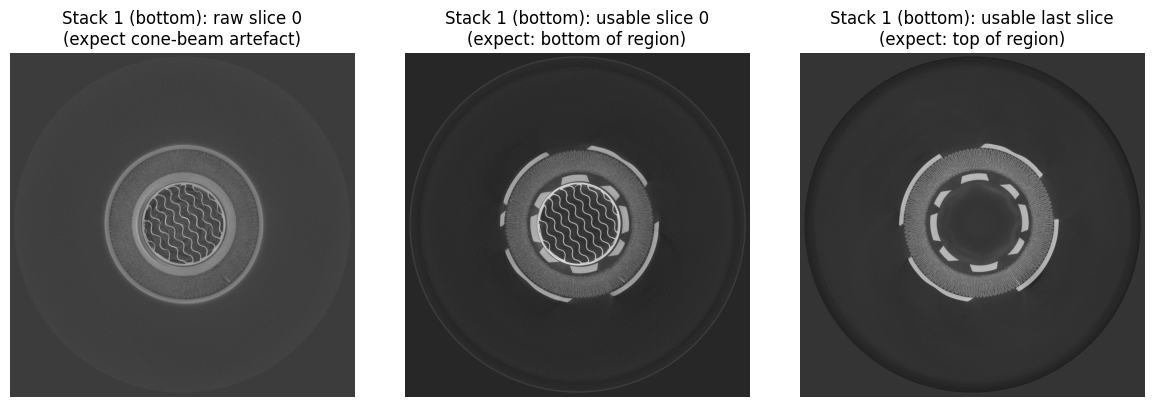

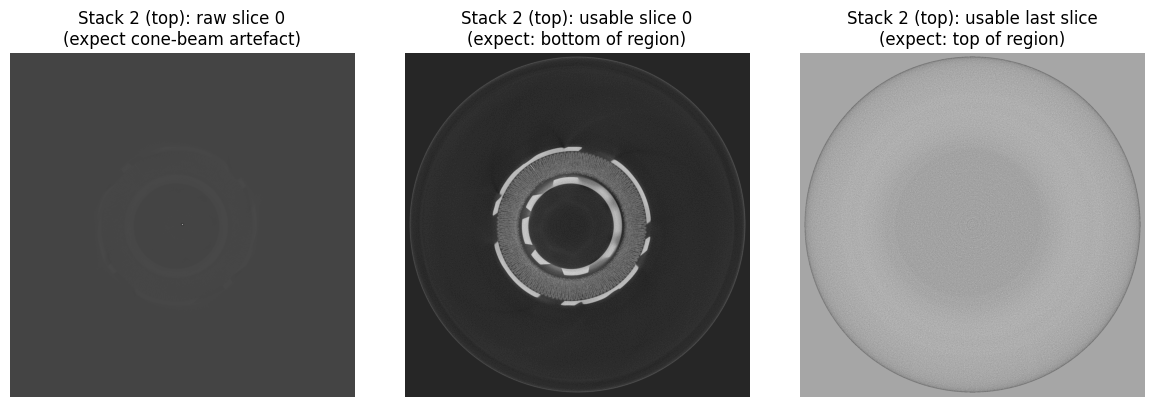

In [6]:
def show_check(mm_raw, mm_usable, name):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(np.asarray(mm_raw[0]), cmap="gray")
    axes[0].set_title(f"{name}: raw slice 0\n(expect cone-beam artefact)")
    axes[1].imshow(np.asarray(mm_usable[0]), cmap="gray")
    axes[1].set_title(f"{name}: usable slice 0\n(expect: bottom of region)")
    axes[2].imshow(np.asarray(mm_usable[-1]), cmap="gray")
    axes[2].set_title(f"{name}: usable last slice\n(expect: top of region)")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_check(mm1_raw, mm1, "Stack 1 (bottom)")
show_check(mm2_raw, mm2, "Stack 2 (top)")

## 4. GPU-accelerated phase correlation

Implements FFT-based phase correlation directly in PyTorch so it runs on GPU: computes the normalized cross-power spectrum via `torch.fft`, finds the integer-pixel peak, then refines to sub-pixel accuracy with a small parabolic fit around the peak in each axis. Falls back to `skimage.registration.phase_cross_correlation` on CPU automatically if CUDA/PyTorch isn't available.

**Memory note:** registration only needs to estimate a translation, so it's run on a central `ROI_SIZE x ROI_SIZE` crop of each slice rather than the full frame - full-resolution FFTs on every candidate overlap size would need far more GPU memory than most cards have. The crop's shift estimate applies directly to the full-resolution data (cropping only changes the window position, not pixel scale); blending/output still use the full-resolution blocks.

In [7]:
def _parabolic_subpixel(corr, peak_idx, axis_sizes):
    """Refine an integer peak index to sub-pixel precision per axis using a 3-point parabolic fit."""
    refined = list(peak_idx)
    for ax in range(len(peak_idx)):
        n = axis_sizes[ax]
        p = peak_idx[ax]
        p_prev = (p - 1) % n
        p_next = (p + 1) % n

        idx_prev = list(peak_idx); idx_prev[ax] = p_prev
        idx_next = list(peak_idx); idx_next[ax] = p_next

        y0 = corr[tuple(idx_prev)]
        y1 = corr[tuple(peak_idx)]
        y2 = corr[tuple(idx_next)]

        denom = (y0 - 2 * y1 + y2)
        if abs(denom) > 1e-8:
            delta = 0.5 * (y0 - y2) / denom
            delta = max(-1.0, min(1.0, float(delta)))  # keep the correction small/sane
        else:
            delta = 0.0
        refined[ax] = p + delta
    return refined


def gpu_phase_cross_correlation(block_a_np, block_b_np, device):
    """
    Returns (shift, error) where shift is (z, y, x) offset to apply to block_b to align with block_a,
    and error is a relative registration-quality score (lower = better).
    """
    a = torch.from_numpy(block_a_np.astype(np.float32)).to(device)
    b = torch.from_numpy(block_b_np.astype(np.float32)).to(device)

    fa = torch.fft.fftn(a)
    fb = torch.fft.fftn(b)
    cross_power = fa * torch.conj(fb)
    cross_power = cross_power / (torch.abs(cross_power) + 1e-8)
    corr = torch.fft.ifftn(cross_power).real

    flat_idx = int(torch.argmax(corr).item())
    shape = tuple(corr.shape)
    peak_idx = list(np.unravel_index(flat_idx, shape))

    peak_val = float(corr[tuple(peak_idx)].item())
    error = 1.0 - peak_val  # corr is normalized, so peak close to 1.0 = good match

    refined_idx = _parabolic_subpixel(corr, peak_idx, shape)

    shifts = []
    for ax, s in enumerate(refined_idx):
        n = shape[ax]
        shift_val = s if s < n / 2 else s - n
        shifts.append(shift_val)

    del a, b, fa, fb, cross_power, corr
    if device != "cpu":
        torch.cuda.empty_cache()
    return np.array(shifts, dtype=float), error


def central_crop(block, roi_size):
    """Crop a centered (roi_size x roi_size) region out of each slice's Y/X plane."""
    _, h, w = block.shape
    roi_h = min(roi_size, h)
    roi_w = min(roi_size, w)
    y0 = (h - roi_h) // 2
    x0 = (w - roi_w) // 2
    return block[:, y0:y0 + roi_h, x0:x0 + roi_w]


def cpu_phase_cross_correlation(block_a_np, block_b_np):
    from skimage.registration import phase_cross_correlation
    shift_est, error, _ = phase_cross_correlation(block_a_np, block_b_np, upsample_factor=4)
    return shift_est, error


def registered_shift(block_a_np, block_b_np, device):
    if TORCH_AVAILABLE and device != "cpu":
        return gpu_phase_cross_correlation(block_a_np, block_b_np, device)
    return cpu_phase_cross_correlation(block_a_np, block_b_np)

## 5. Overlap search + blending + brightness correction

Same approach as the 3-scan version: registration search runs on a small ROI crop for memory efficiency, and the brightness correction is built as a reusable lookup table (LUT) from the overlap region so it can be applied across the *entire* top stack later, not just the seam.

In [8]:
def find_best_overlap(mm_a, mm_b, approx_overlap, margin, device, roi_size=ROI_SIZE, min_overlap=10):
    max_n = approx_overlap + margin
    max_n = min(max_n, mm_a.shape[0], mm_b.shape[0])

    block_a_full = np.asarray(mm_a[-max_n:])
    block_b_full = np.asarray(mm_b[:max_n])

    block_a_crop_full = central_crop(block_a_full, roi_size)
    block_b_crop_full = central_crop(block_b_full, roi_size)

    candidates = range(max(min_overlap, approx_overlap - margin), max_n + 1)
    best = None

    for n in candidates:
        block_a_crop = block_a_crop_full[-n:]
        block_b_crop = block_b_crop_full[:n]
        shift_est, error = registered_shift(block_a_crop, block_b_crop, device)
        if best is None or error < best[2]:
            best = (n, shift_est, error)

    n, shift_est, error = best
    print(f"[{device}] Best overlap: {n} slices (ROI {roi_size}x{roi_size}), "
          f"shift(z,y,x)={shift_est}, error={error:.4f}")
    return n, shift_est, error, block_a_full, block_b_full


def build_histogram_lut(source_block, reference_block):
    """
    Builds a lookup table mapping source_block's gray values onto reference_block's distribution,
    via cumulative-histogram (quantile) matching - exposed as a reusable table (lut[value] ->
    corrected value) so it can be applied to an entire stack, not just the block it was
    estimated from.
    """
    dtype = source_block.dtype
    if not np.issubdtype(dtype, np.integer):
        raise ValueError(
            f"build_histogram_lut expects integer CT data (got {dtype}) - "
            "adjust this function if your reconstructions are float."
        )

    src_values, src_counts = np.unique(source_block.ravel(), return_counts=True)
    ref_values, ref_counts = np.unique(reference_block.ravel(), return_counts=True)

    src_quantiles = np.cumsum(src_counts).astype(np.float64) / source_block.size
    ref_quantiles = np.cumsum(ref_counts).astype(np.float64) / reference_block.size

    interp_ref_values = np.interp(src_quantiles, ref_quantiles, ref_values)

    max_val = np.iinfo(dtype).max
    full_range = np.arange(max_val + 1)
    lut = np.interp(
        full_range, src_values, interp_ref_values,
        left=interp_ref_values[0], right=interp_ref_values[-1],
    )
    return np.clip(np.round(lut), 0, max_val).astype(dtype)


def apply_lut(block, lut):
    return block if lut is None else lut[block]


def feather_blend(block_a, block_b):
    n = block_a.shape[0]
    weights = np.linspace(1, 0, n).reshape(-1, 1, 1)
    blended = block_a.astype(np.float32) * weights + block_b.astype(np.float32) * (1 - weights)
    return blended.astype(block_a.dtype)


def compute_overlap_blend(mm_a, mm_b, approx_overlap, margin, device, feather=True, label=""):
    print(f"Finding overlap ({label}) on {device}...")
    n, shift_est, error, block_a_full, block_b_full = find_best_overlap(
        mm_a, mm_b, approx_overlap, margin, device
    )

    block_a = block_a_full[-n:]
    block_b = block_b_full[:n]

    block_b_aligned = nd_shift(block_b.astype(np.float32), shift=shift_est, order=1, mode="nearest")
    block_b_aligned = block_b_aligned.astype(block_b.dtype)

    # source=block_b (top's overlap), reference=block_a (bottom's overlap) - bottom is the
    # brightness reference, top gets corrected onto its scale.
    lut = build_histogram_lut(block_b_aligned, block_a)
    block_b_corrected = apply_lut(block_b_aligned, lut)

    blended = feather_blend(block_a, block_b_corrected) if feather else block_a

    del block_a_full, block_b_full
    return n, blended, lut

## 6. Run the overlap registration

In [9]:
n_overlap, blended, lut_top = compute_overlap_blend(
    mm1, mm2, APPROX_OVERLAP, SEARCH_MARGIN, DEVICE, feather=FEATHER, label="bottom/top"
)

print(f"\noverlap: {n_overlap} slices")

Finding overlap (bottom/top) on cuda:0...
[cuda:0] Best overlap: 99 slices (ROI 1028x1028), shift(z,y,x)=[ 7.24344999e-02 -2.22748039e+01  8.02754720e+01], error=0.9983

overlap: 99 slices


## 7. Streaming write helpers

In [10]:
def stream_copy(writer, mm_vol, start, end, chunk_size=CHUNK_SIZE, label="", lut=None):
    total = end - start
    if total <= 0:
        return
    for i in range(start, end, chunk_size):
        j = min(i + chunk_size, end)
        block = np.asarray(mm_vol[i:j])
        block = apply_lut(block, lut)
        for s in range(block.shape[0]):
            writer.write(block[s], contiguous=True)
        done = j - start
        print(f"  {label}: wrote {done}/{total} slices", end="\r")
    print()


def stream_write_block(writer, block, lut=None):
    block = apply_lut(block, lut)
    for s in range(block.shape[0]):
        writer.write(block[s], contiguous=True)

## 8. Stream the stitched volume to disk

`mm1` (bottom) is the brightness reference, written unchanged. `mm2` (top) has `lut_top` applied throughout, so it lands on the same scale as bottom. The blended overlap block was already brought onto bottom's scale in step 5/6, so it's written as-is here.

In [11]:
OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)

len1, len2 = mm1.shape[0], mm2.shape[0]

with tifffile.TiffWriter(OUTPUT_FILE, bigtiff=True) as writer:
    stream_copy(writer, mm1, 0, len1 - n_overlap, label="stack 1 (head)")     # bottom: reference, no LUT
    stream_write_block(writer, blended)                                       # already bottom-scale
    stream_copy(writer, mm2, n_overlap, len2, label="stack 2 (tail)", lut=lut_top)

final_len = (len1 - n_overlap) + n_overlap + (len2 - n_overlap)
print(f"\nDone. Stitched volume written to {OUTPUT_FILE}")
print(f"Final slice count: {final_len}")

  stack 1 (head): wrote 1529/1529 slices
  stack 2 (tail): wrote 1529/1529 slices

Done. Stitched volume written to /home/charlie/usb_drive/Charlie/data/Stitched/2_stitches_stitched.tif
Final slice count: 3157


## 9. Sanity check the output

Stitched volume shape: (3157, 2028, 2028) dtype: uint16


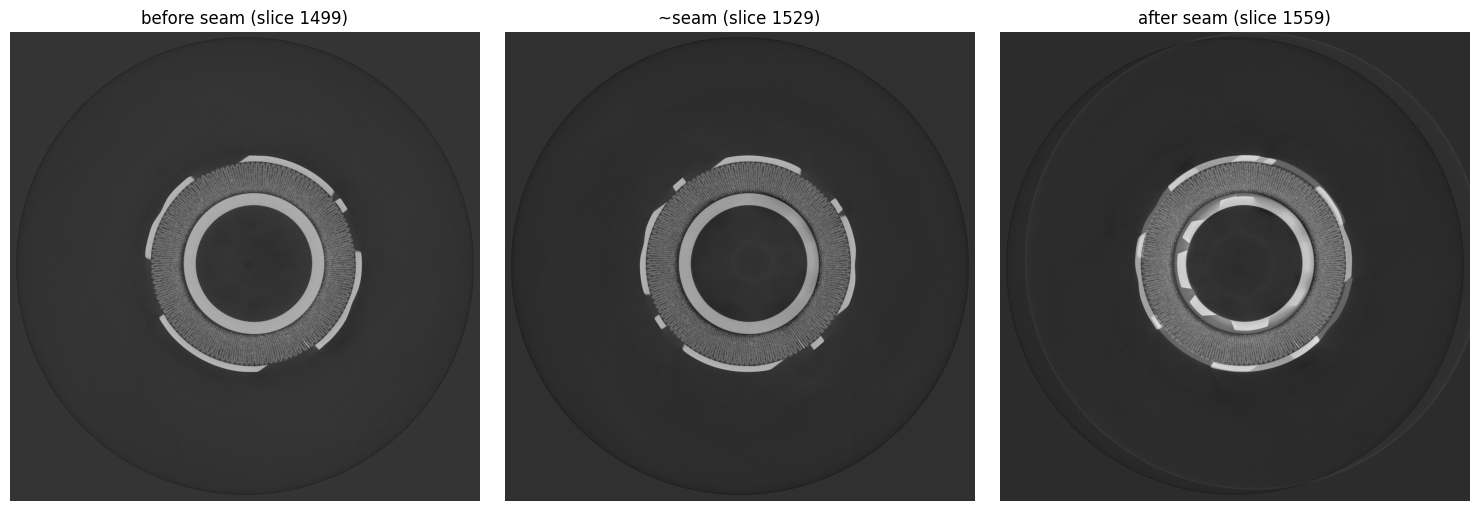

In [12]:
stitched = tifffile.memmap(OUTPUT_FILE, mode="r")
print("Stitched volume shape:", stitched.shape, "dtype:", stitched.dtype)

seam = len1 - n_overlap

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, idx, title in zip(
    axes,
    [max(0, seam - 30), seam, min(stitched.shape[0] - 1, seam + 30)],
    ["before seam", "~seam", "after seam"],
):
    ax.imshow(np.asarray(stitched[idx]), cmap="gray")
    ax.set_title(f"{title} (slice {idx})")
    ax.axis("off")
plt.tight_layout()
plt.show()

## Notes / troubleshooting

- **PyTorch/CUDA not detected:** check `torch.cuda.is_available()` in the setup cell output. If
  `False`, verify your CUDA driver + PyTorch build match (see
  https://pytorch.org/get-started/locally/, matching your CUDA version). The notebook will still
  run correctly on CPU via the automatic fallback, just slower.
- **`AcceleratorError: no kernel image is available`:** your PyTorch build doesn't include kernels
  for your GPU's compute capability - check `torch.cuda.get_device_capability(0)` and confirm your
  installed PyTorch version still supports it (older GPU architectures are dropped in newer
  PyTorch releases).
- **Flip direction wrong / cone-beam trim insufficient:** check step 3's thumbnails before running
  the full stitch - getting this wrong silently produces a scrambled volume.
- **`OutOfMemoryError` on the GPU during registration:** lower `ROI_SIZE` (e.g. to 256) - this
  directly controls how much data each FFT call needs to hold in VRAM.
- **Still see a brightness jump between stacks:** check that `build_histogram_lut`'s source/reference
  blocks actually contain representative material (not mostly air/background). You can inspect
  `lut_top` directly (`plt.plot(lut_top)`) - a sensible correction should look like a smooth,
  mostly-monotonic curve.
- **Registration seems inaccurate:** increase `ROI_SIZE` for more structure to lock onto, or widen
  `SEARCH_MARGIN` if the true overlap might be outside the current search window.
- **Want maximum registration precision over speed:** set `DEVICE = "cpu"` in step 1 to force the
  more rigorous skimage upsampled-DFT path instead of the GPU parabolic-refinement path.
- **Disk space:** you need room for both raw stacks plus the full stitched output simultaneously.


## 10. Time-lapse viewer - play through the whole stitched volume

An interactive player (play button + scrub slider) for reviewing the entire stitched volume.
Reads slices from the memmap on demand, so it stays lightweight even on a large stack.

**Requirements:** `pip install ipywidgets pillow`


In [13]:
import ipywidgets as widgets
from IPython.display import display
from PIL import Image
import io

SLICE_STEP = 5            # view every Nth slice
DISPLAY_DOWNSAMPLE = 4     # in-plane downsample factor for the viewer only
PLAY_INTERVAL_MS = 80      # milliseconds between frames during playback

indices = list(range(0, stitched.shape[0], SLICE_STEP))

sample_idxs = indices[::max(1, len(indices) // 20)]
sample_stack = np.stack([
    np.asarray(stitched[i])[::DISPLAY_DOWNSAMPLE, ::DISPLAY_DOWNSAMPLE] for i in sample_idxs
])
vmin, vmax = np.percentile(sample_stack, [0.5, 99.5])
del sample_stack


def to_png_bytes(slice_idx):
    frame = np.asarray(stitched[slice_idx])[::DISPLAY_DOWNSAMPLE, ::DISPLAY_DOWNSAMPLE].astype(np.float32)
    frame = np.clip((frame - vmin) / (vmax - vmin + 1e-8) * 255, 0, 255).astype(np.uint8)
    buf = io.BytesIO()
    Image.fromarray(frame).save(buf, format="PNG")
    return buf.getvalue()


image_widget = widgets.Image(value=to_png_bytes(indices[0]), format="png", width=500)
label_widget = widgets.Label(value=f"slice {indices[0]}/{stitched.shape[0] - 1}")


def on_change(change):
    slice_idx = indices[change["new"]]
    image_widget.value = to_png_bytes(slice_idx)
    label_widget.value = f"slice {slice_idx}/{stitched.shape[0] - 1}"


play = widgets.Play(min=0, max=len(indices) - 1, step=1, interval=PLAY_INTERVAL_MS, description="Play")
slider = widgets.IntSlider(min=0, max=len(indices) - 1, step=1, description="frame")
widgets.jslink((play, "value"), (slider, "value"))
slider.observe(on_change, names="value")

display(widgets.VBox([widgets.HBox([play, slider]), label_widget, image_widget]))